In [ ]:
import pandas as pd
import numpy as np
df = pd.read_stata('Integration.dta')
import mymlr as mlr # see mymlr.py
df

,id,mand,ankomstaar,alder,aarslon,aar
0,1.0,1.0,2014.0,26.0,57334.093750,2017.0
1,1.0,1.0,2014.0,27.0,153148.484375,2018.0
2,2.0,0.0,2016.0,36.0,28191.710938,2017.0
3,2.0,0.0,2016.0,37.0,33956.566406,2018.0
4,3.0,1.0,2014.0,33.0,106868.898438,2017.0
...,...,...,...,...,...,...
4795,2398.0,1.0,2014.0,36.0,191616.437500,2018.0
4796,2399.0,1.0,2015.0,22.0,44208.378906,2017.0
4797,2399.0,1.0,2015.0,23.0,43788.902344,2018.0
4798,2400.0,1.0,2015.0,24.0,116806.382812,2017.0


In [54]:
#1.a.
# Descriptive analysis

df['2014'] = (df.ankomstaar == 2014.0)
df['2014'] = df['2014'].astype('int')
df['2015'] = (df.ankomstaar == 2015.0)
df['2015'] = df['2015'].astype('int')
df['2016'] = (df.ankomstaar == 2016.0)
df['2016'] = df['2016'].astype('int')

#Tabel
raekker = ['aarslon', 'alder', '2014', '2015', '2016']
tabel = df.groupby(['mand', 'aar'])[raekker].mean().T
tabel = tabel.round(2)
tabel


mand          0.0                 1.0          
aar        2017.0    2018.0    2017.0    2018.0
aarslon  31124.44  40045.05  61324.05  90906.50
alder       28.63     29.63     28.67     29.67
2014         0.34      0.34      0.33      0.33
2015         0.34      0.34      0.32      0.32
2016         0.32      0.32      0.35      0.35

In [61]:
#1.b.

df['YSM'] = df['aar'] - df['ankomstaar'] #years since migration
df17 = df[df['aar'] == 2017].copy() #tværsnit for 2017

df17['const'] = 1 #tilføjer en konstant
X = df17[['const', 'alder', 'YSM']].values #forklarende variable
y = np.log(df17['aarslon']).values

n = X.shape[0] #antal rækker = 2400
k = X.shape[1] - 1  # antal forklarende variable (kolonner) (ikke inkl. konstant)

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta_hat
residualer = y - y_hat
SSR = np.sum(residualer ** 2) #Sum of squared residuals

sigma2_hat = SSR/(n-k-1)

se_beta = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))) #standarderror


print(f"beta_0: estimat = {beta_hat[0]:.4f}, std. fejl = {se_beta[0]:.4f}")
print(f"beta_1: estimat = {beta_hat[1]:.4f}, std. fejl = {se_beta[1]:.4f}")
print(f"beta_2:   estimat = {beta_hat[2]:.4f}, std. fejl = {se_beta[2]:.4f}")

variable = ['-', 'alder', 'YSM']
koefficienter = ['beta_0', 'beta_1', 'beta_2']

tabel_1b = pd.DataFrame({
    'Koeffient': coef,
    'Variabel': navne,
    'Estimat' : beta_hat,
    'Standardfejl' : se_beta
})
tabel_1b.round(4)


beta_0: estimat = 10.4231, std. fejl = 0.0474
beta_1: estimat = 0.0071, std. fejl = 0.0014
beta_2:   estimat = 0.0870, std. fejl = 0.0119


,Koeffient,Variabel,Estimat,Standardfejl
0,beta_0,-,10.4231,0.0474
1,beta_1,alder,0.0071,0.0014
2,beta_2,YSM,0.0870,0.0119


In [76]:
#1b
# import statsmodels.api as sm

# model_1 = sm.OLS(y, X).fit()
# print(model_1.summary())

In [ ]:
#1c
df17['YSM-alder'] = df['YSM'] - df['alder'] #tilføjer ny variabel (YSM - alder)

X = df17[['const', 'alder', 'YSM-alder']].values #model med nye variable
y = np.log(df17['aarslon']).values

n = X.shape[0] #antal rækker = 2400
k = X.shape[1] - 1  # antal forklarende variable (kolonner) (ikke inkl. konstant)

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta_hat
residualer = y - y_hat
SSR = np.sum(residualer ** 2) #Sum of squared residuals

sigma2_hat = SSR/(n-k-1)

se_beta = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))) #standarderror


print(f"beta_0: estimat = {beta_hat[0]:.4f}, std. fejl = {se_beta[0]:.4f}")
print(f"theta: estimat = {beta_hat[1]:.4f}, std. fejl = {se_beta[1]:.4f}")
print(f"beta_2:   estimat = {beta_hat[2]:.4f}, std. fejl = {se_beta[2]:.4f}")

tabel_1b = pd.DataFrame({
    'Koefficient': koefficienter,
    'Variabel': variable,
    'Estimat' : beta_hat,
    'Standardfejl' : se_beta
})
tabel_1b.round(4)

beta_0: estimat = 10.4231, std. fejl = 0.0474
theta: estimat = 0.0942, std. fejl = 0.0120
beta_2:   estimat = 0.0870, std. fejl = 0.0119


,Koefficient,Variabel,Estimat,Standardfejl
0,beta_0,-,10.4231,0.0474
1,theta,alder,0.0942,0.0120
2,beta_2,(YSM - alder),0.0870,0.0119


In [77]:
# #1c
# model_1c = sm.OLS(y,X).fit() #Estimation af ny model
# print(model_1c.summary()) 

In [70]:
#2.a.

df['const'] = 1 #tilføjer konstant til df
X = df[['const', 'alder', 'YSM', 'ankomstaar']].values #forklarende variable
y = np.log(df['aarslon']).values

n = X.shape[0] #antal rækker = 4800
k = X.shape[1] - 1  # antal forklarende variable (kolonner) (ikke inkl. konstant)

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

y_hat = X @ beta_hat
residualer = y - y_hat
SSR = np.sum(residualer ** 2) #Sum of squared residuals

sigma2_hat = SSR/(n-k-1)

se_beta = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))) #standarderror


print(f"beta_0: estimat = {beta_hat[0]:.4f}, std. fejl = {se_beta[0]:.4f}")
print(f"beta_1: estimat = {beta_hat[1]:.4f}, std. fejl = {se_beta[1]:.4f}")
print(f"beta_2:   estimat = {beta_hat[2]:.4f}, std. fejl = {se_beta[2]:.4f}")
print(f"beta_3:   estimat = {beta_hat[3]:.4f}, std. fejl = {se_beta[3]:.4f}")



beta_0: estimat = -457.8689, std. fejl = 38.8181
beta_1: estimat = 0.0056, std. fejl = 0.0012
beta_2:   estimat = 0.2889, std. fejl = 0.0165
beta_3:   estimat = 0.2322, std. fejl = 0.0192


In [75]:
#3.a.

df['alder2'] = df['alder'] ** 2
df['YSM2'] = df['YSM'] ** 2

df['kohorte15'] = (df.ankomstaar == 2015.0).astype(int)
df['kohorte16'] = (df.ankomstaar == 2016.0).astype(int)

X = df[['const', 'alder', 'alder2', 'YSM', 'YSM2', 'kohorte15', 'kohorte16']]
y = np.log(df['aarslon'])

model3 = sm.OLS(y,X).fit()
results = model3.summary()
print(results)




                            OLS Regression Results                            
Dep. Variable:                aarslon   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     114.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):          1.48e-135
Time:                        13:06:23   Log-Likelihood:                -3961.5
No. Observations:                4800   AIC:                             7937.
Df Residuals:                    4793   BIC:                             7982.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0633      0.128     62.821      0.0

In [ ]:
#3.b.(i)

from scipy import stats

df['kohorte_lin'] = df['kohorte15'] + 2 * df['kohorte16']
X_r = df[['const', 'alder', 'YSM', 'kohorte_lin']]

model_r = sm.OLS(y, X_r).fit()

SSR_r = model_r.ssr
SSR_ur = model3.ssr
q = 3 #antal restriktioner
n = len(y) #antal observationer
k_ur = 6 #forklarende variable i urestrikterede model

F_stat = ((SSR_r - SSR_ur) / q) / (SSR_ur / (n - k - 1))
p = stats.f.sf(F, q, n-k-1)

print(f'{F_stat = :.4f}')
print(f'{p = :.2e}')


F_stat = 96.3058
p = 1.59e-60


In [97]:
#3.b.(ii)

y = np.log(df['aarslon'])
X = df[['const', 'alder', 'alder2', 'YSM', 'YSM2', 'kohorte15', 'kohorte16']]

mand = df['mand'] == 1 
kvinde = df['mand'] == 0

# Samlet (restrikteret) model = model (3)
model_r = sm.OLS(y, X).fit()

#Separate modeller
model_m = sm.OLS(y[mand],  X[mand]).fit()
model_k = sm.OLS(y[kvinde], X[kvinde]).fit()

#SSR'er
SSR_r  = model_r.ssr
SSR_ur = model_m.ssr + model_k.ssr

#Chow-test
k   = 6
n   = len(y)
q   = 7                    # 7 restriktioner -> alle 7 koefficienter skal være ens
df2 = n - 2*(k + 1)            # 4786 -> antal frihedsgrader i den urestrikterede model

F = ((SSR_r - SSR_ur) / q) / (SSR_ur / df2)
p = stats.f.sf(F, q, df2)

print(f'{F = :.4f}')
print(f'{p = :.2e}')


F = 321.4585
p = 0.00e+00


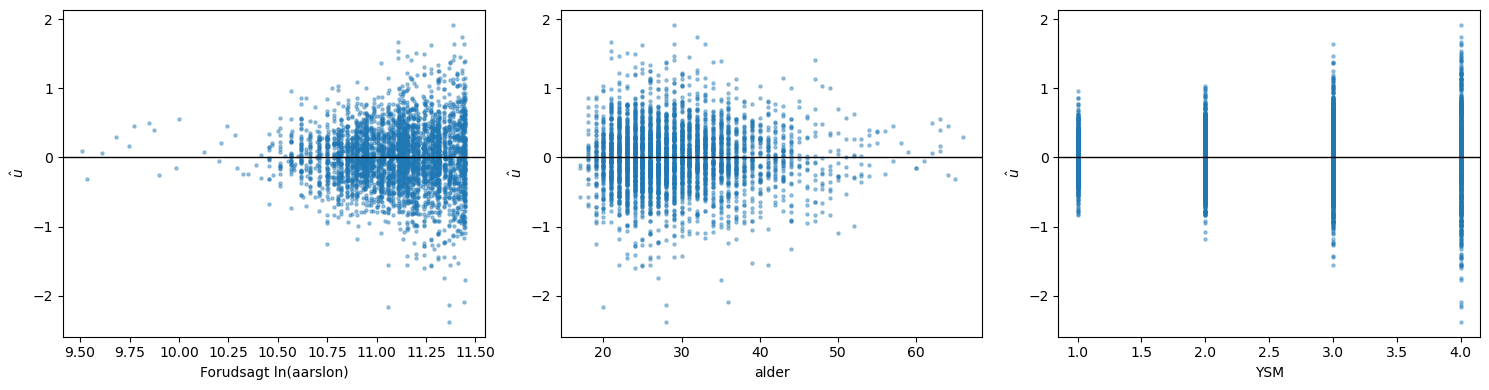

In [ ]:
#3.c
import matplotlib.pyplot as plt

u_hat  = model_m.resid
y_hat  = model_m.fittedvalues
X_m    = X[mand]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, (x, navn) in zip(axs, [(X_m['alder'], 'alder'),
                               (X_m['YSM'], 'YSM')]):
    ax.scatter(x, u_hat, s=5, alpha=0.4)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel(navn)
    ax.set_ylabel(r'$\hat{u}$')

plt.tight_layout()
plt.show()

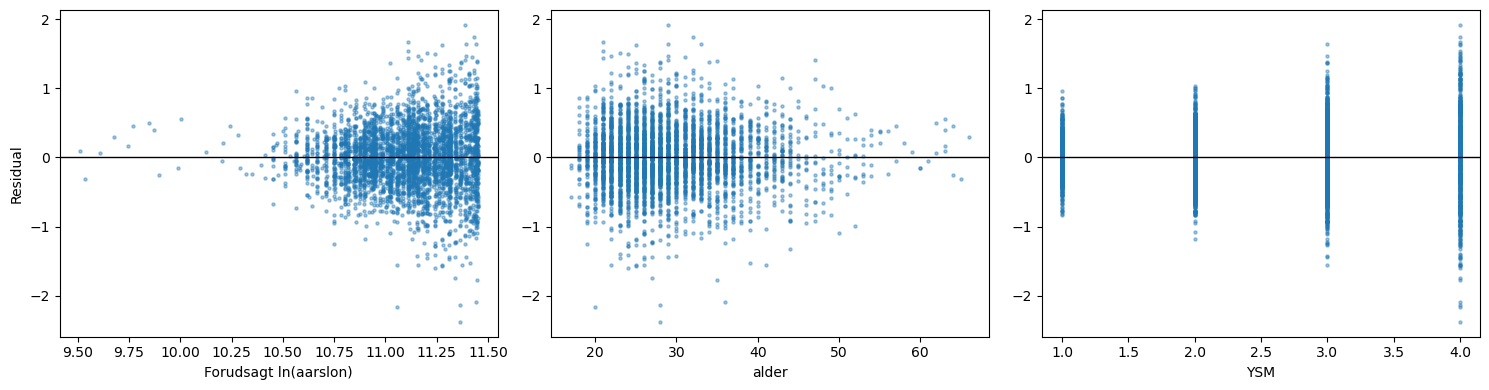

In [98]:
#3.c

import matplotlib.pyplot as plt

X_m = X[mand]
y_m = y[mand]
model_m = sm.OLS(y_m, X_m).fit()

res = model_m.resid
fitted = model_m.fittedvalues

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(fitted, res, s=5, alpha=0.4)
axs[0].set_xlabel('Forudsagt ln(aarslon)'); axs[0].set_ylabel('Residual')

axs[1].scatter(X_m['alder'], res, s=5, alpha=0.4)
axs[1].set_xlabel('alder')

axs[2].scatter(X_m['YSM'], res, s=5, alpha=0.4)
axs[2].set_xlabel('YSM')

for ax in axs:
    ax.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()